In [ ]:
#UPDATED VERSION!!

import kagglehub

# Download latest version
path = kagglehub.dataset_download("hummaamqaasim/jobs-in-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\hummaamqaasim\jobs-in-data\versions\6


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style(style='ticks')

#Load the dataset
df = pd.read_csv('jobs_in_data.csv')
df.head()

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M


In [65]:
#FOCUS ON POPULAR JOB TITLE
#salary trend of data analyst job over the year?
#work_setting salary comparison (i.e. remote vs in-person vs hybrid)
	#compare only the same level of experience to avoid skewed distribution.

#salary comparison of job titles (entry level vs entry level, ... , exec vs exec)
#check which company size offers more salary


#advanced: linear regression for salary of data analyst, data scientist
    #find out if job_title is significant factor in salary
    #

#REMINDER: ALWAYS CHECK THE DATASET's DOCUMENTATION IN KAGGLE!!!! (FOR IDEAS ON WHAT INSIGHTS CAN POSSIBLY GATHERED IN THIS DATASET!!)

#QUESTIONS TO ANSWER:
#1.) FINDING JOBS BASED ON WORK SETTING.
#2.) FINDING JOBS BASED ON EXPERIENCE LEVEL.
#3.) FINDING JOBS CONSIDERING BOTH 1.) AND 2.).
#4.) FINDING JOBS CONDIERING EMPLOYMENT TYPE.

#CONSIDER:
#JOBS OF TOP 3 DATA CATEGORY (REGARDLESS OF EXPERIENCE LEVEL WITH DIFFERENT employee_location and company_location) CHECK THE WORTHNIESS IF I WERE TO HAVE THAT JOB
#OBVIOUSLY, USE THE COST OF LIVING IN THE PHILIPPINES


In [66]:
#For this analysis, we only consider company located in the United States.
df_US = df[df['company_location'] == 'United States']
df_US.head()

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M
5,2023,Data Scientist,Data Science and Research,USD,130000,130000,United States,Senior,Full-time,Remote,United States,M


In [67]:
#Getting initial insights in our data.
df_US.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8132 entries, 1 to 9354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           8132 non-null   int64 
 1   job_title           8132 non-null   object
 2   job_category        8132 non-null   object
 3   salary_currency     8132 non-null   object
 4   salary              8132 non-null   int64 
 5   salary_in_usd       8132 non-null   int64 
 6   employee_residence  8132 non-null   object
 7   experience_level    8132 non-null   object
 8   employment_type     8132 non-null   object
 9   work_setting        8132 non-null   object
 10  company_location    8132 non-null   object
 11  company_size        8132 non-null   object
dtypes: int64(3), object(9)
memory usage: 825.9+ KB


In [ ]:
#Get the top 3 data job categories in the United States
df_US['job_category'].value_counts().head(3)

top_3_job = df_US['job_category'].value_counts().head(3).index.to_list()
top_3_job

['Data Science and Research', 'Data Engineering', 'Data Analysis']

In [69]:
df_US_top3 = df_US[df_US['job_category'].isin(top_3_job)]
df_US_top3

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M
5,2023,Data Scientist,Data Science and Research,USD,130000,130000,United States,Senior,Full-time,Remote,United States,M
6,2023,Data Scientist,Data Science and Research,USD,100000,100000,United States,Senior,Full-time,Remote,United States,M
9,2023,Data Engineer,Data Engineering,USD,210000,210000,United States,Executive,Full-time,Remote,United States,M
...,...,...,...,...,...,...,...,...,...,...,...,...
9344,2020,Data Engineer,Data Engineering,USD,130800,130800,Spain,Mid-level,Full-time,Remote,United States,M
9351,2020,Data Scientist,Data Science and Research,USD,412000,412000,United States,Senior,Full-time,Remote,United States,L
9352,2021,Principal Data Scientist,Data Science and Research,USD,151000,151000,United States,Mid-level,Full-time,Remote,United States,L
9353,2020,Data Scientist,Data Science and Research,USD,105000,105000,United States,Entry-level,Full-time,Remote,United States,S


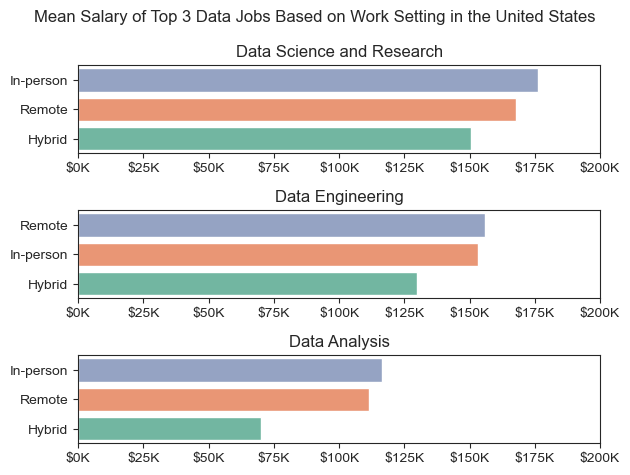

In [ ]:
#work_setting salary comparison (i.e. remote vs in-person vs hybrid)
#compare same job title, different work setting
#clean the plot using sns

mean_work_setting = df_US_top3.groupby(['job_category', 'work_setting'])['salary_in_usd'].mean()
mean_work_setting = mean_work_setting.reset_index(name='mean_salary')
mean_work_setting = mean_work_setting.sort_values(by='mean_salary', ascending=False)
fig, ax = plt.subplots(3,1)
for i,job in enumerate(top_3_job):
    mean_work_setting_plot = mean_work_setting[mean_work_setting['job_category'] == job]
    sns.barplot(data=mean_work_setting_plot, y='work_setting', x='mean_salary', legend=False, ax=ax[i], palette='Set2', hue='mean_salary')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,200000)
    ax[i].set_xlabel('')
    ax[i].set_title(job)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.suptitle('Mean Salary of Top 3 Data Jobs Based on Work Setting in the United States')
plt.tight_layout()
plt.show()

#we see a trend where Hybrid jobs pays only more or less half as the other 2 work settings.
#deep dive for the reason why is this happening.


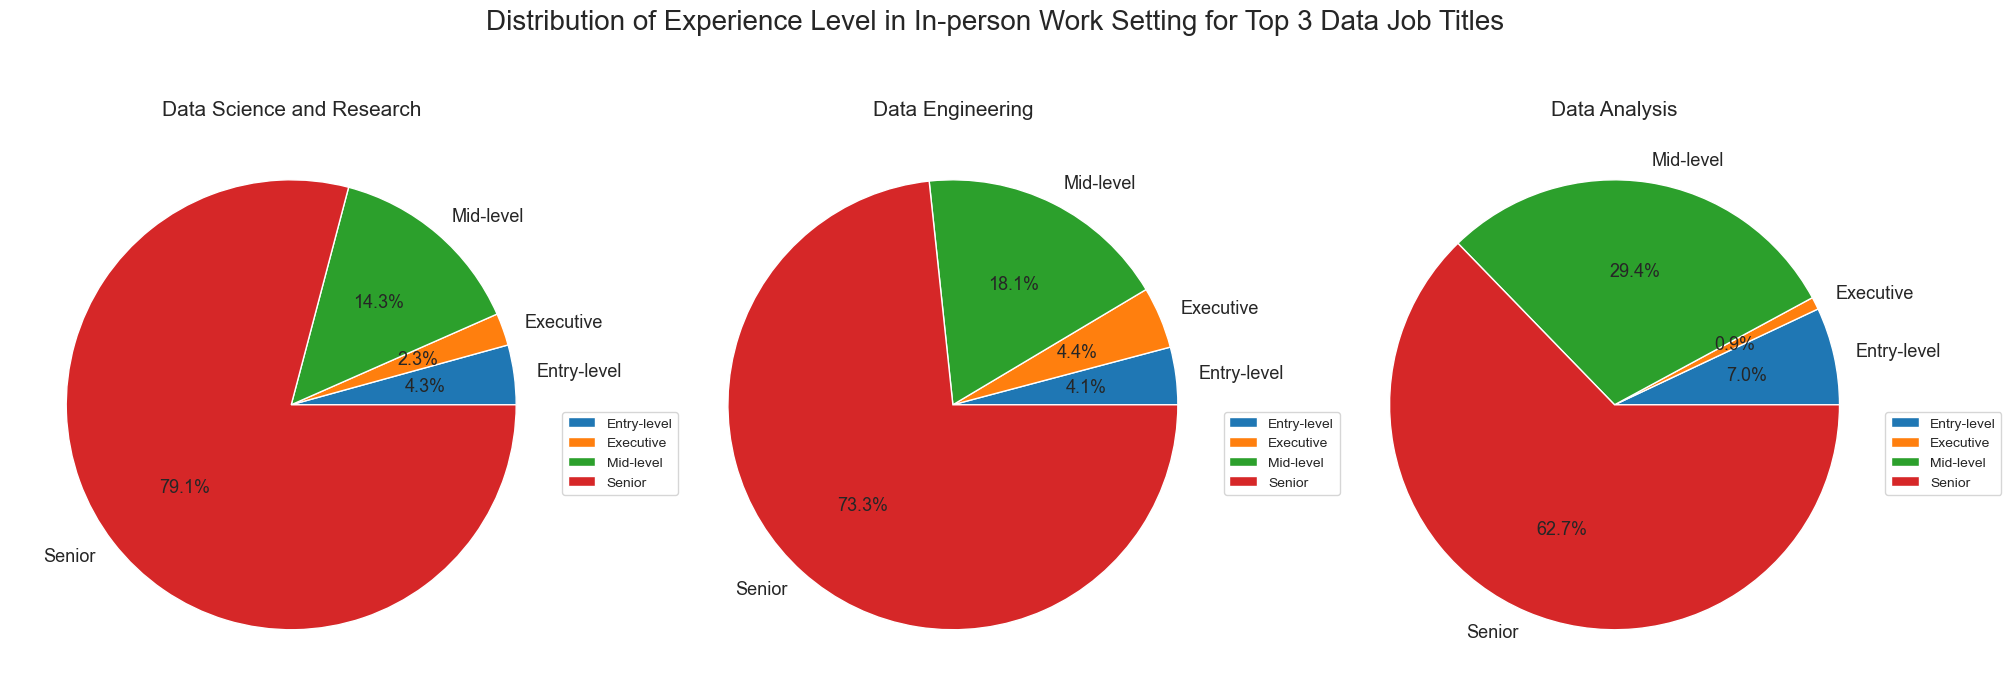

In [ ]:
#exploring the reason behind hybrid work setting pays significantly less than the others.
#produce graph showing hybrid work setting does not offer an executive position and hence, no salary, which causes for Hybrid mean salary to drop significantly.
df_US_distribution = df_US_top3.groupby(['job_category', 'work_setting', 'experience_level'],dropna=False).size()
df_US_distribution = df_US_distribution.reset_index(name='job_count')

df_US_inperson = df_US_distribution[df_US_distribution['job_category'].isin(top_3_job)]
df_US_inperson = df_US_inperson[df_US_inperson['work_setting'] == 'In-person']
df_US_inperson = df_US_inperson.set_index('job_category')

fig,ax = plt.subplots(1,3, figsize=(20,15))
for i,job in enumerate(top_3_job):
    ax[i].pie(data=df_US_inperson.loc[job], x='job_count', labels=df_US_inperson.loc[job]['experience_level'], autopct='%1.1f%%', textprops={'fontsize': 13})
    ax[i].set_title(job, fontsize=15)
    ax[i].legend(loc='upper right', bbox_to_anchor=(1.2,0.5))
plt.suptitle('Distribution of Experience Level in In-person Work Setting for Top 3 Data Job Titles', y=0.75, fontsize=20)
plt.tight_layout()
#as can be observed, both DS and DA does not have Hybrid setting for executive position. Also, one can notice that Data Engineer has executive position, but only for 5%.
#this causes mean salary for hybrid work setting to be significantly lower.

In [72]:
df_US_distribution = df_US_distribution[df_US_distribution['work_setting'] == 'In-person']
df_US_distribution

,job_category,work_setting,experience_level,job_count
2,Data Analysis,In-person,Entry-level,47
3,Data Analysis,In-person,Executive,6
4,Data Analysis,In-person,Mid-level,197
5,Data Analysis,In-person,Senior,421
12,Data Engineering,In-person,Entry-level,54
13,Data Engineering,In-person,Executive,58
14,Data Engineering,In-person,Mid-level,237
15,Data Engineering,In-person,Senior,959
23,Data Science and Research,In-person,Entry-level,72
24,Data Science and Research,In-person,Executive,39


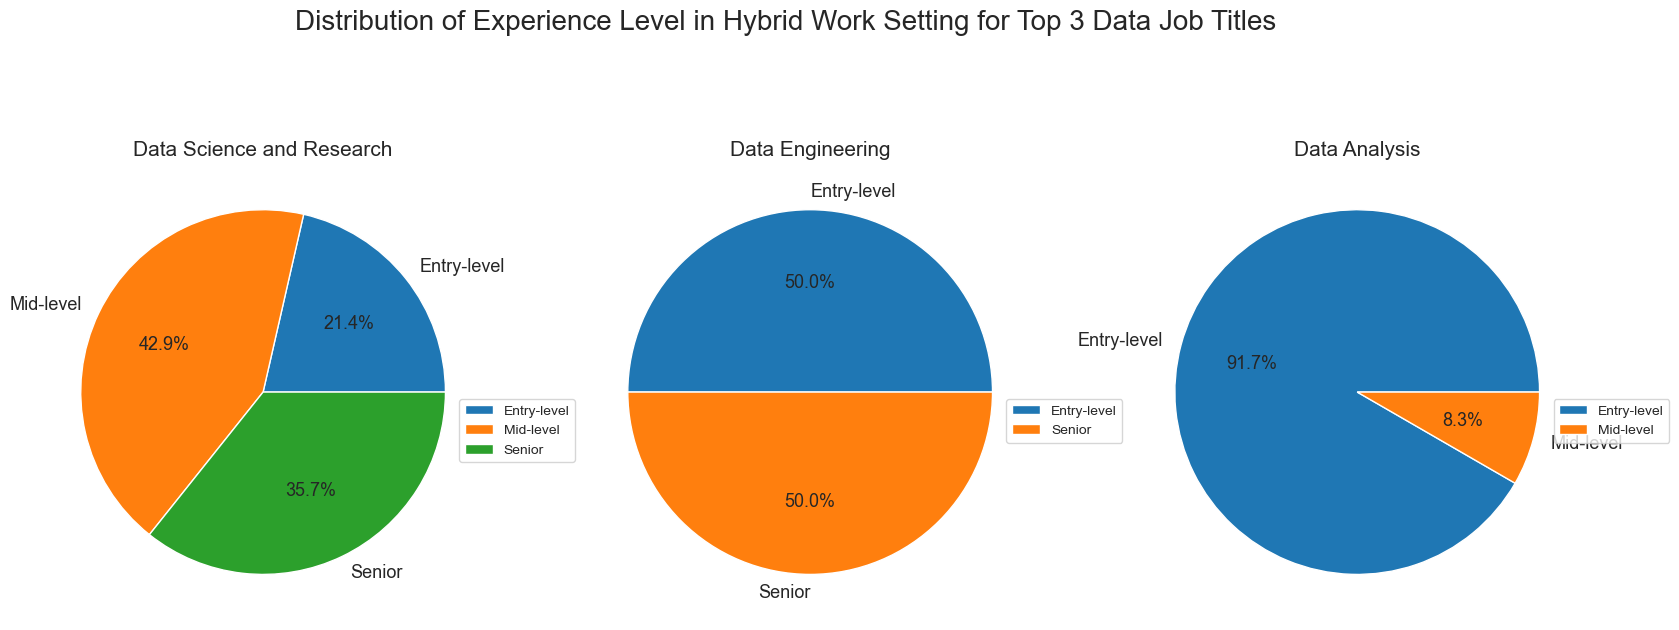

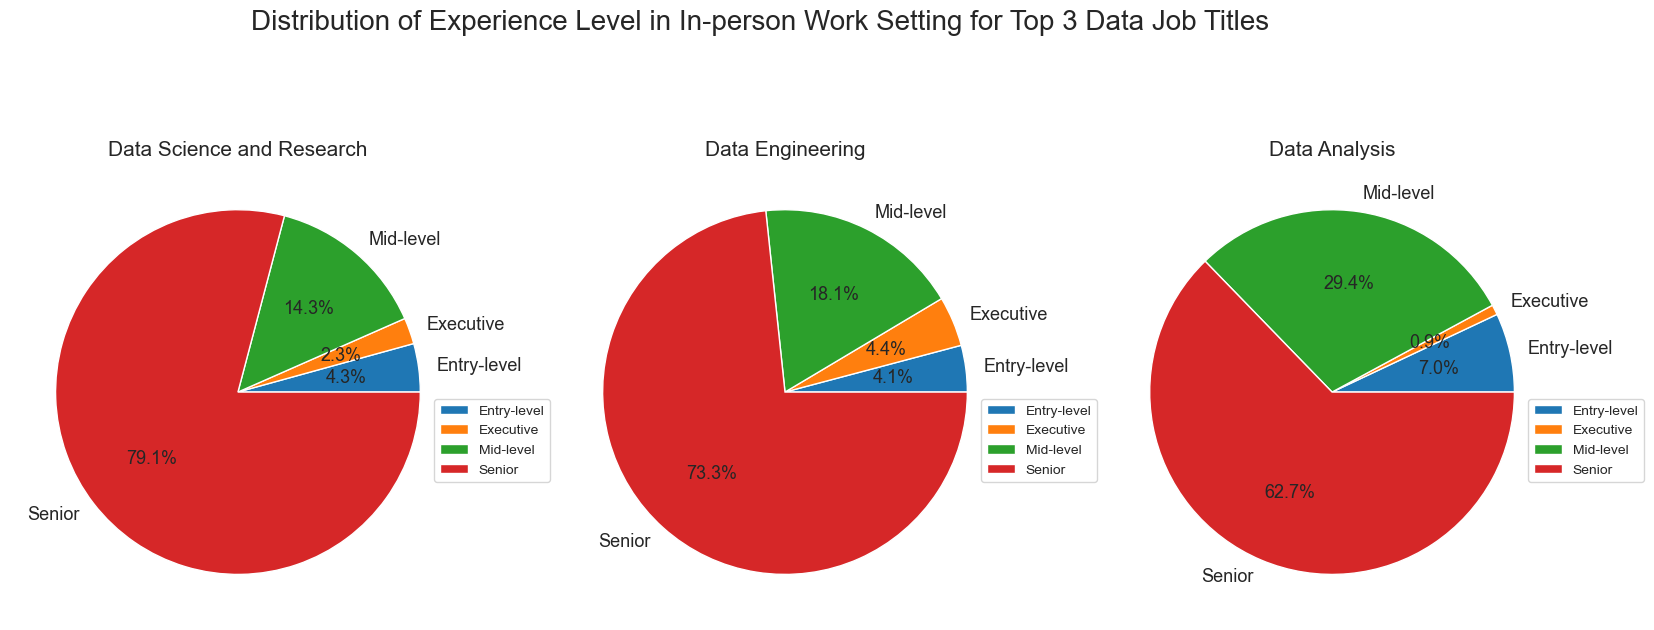

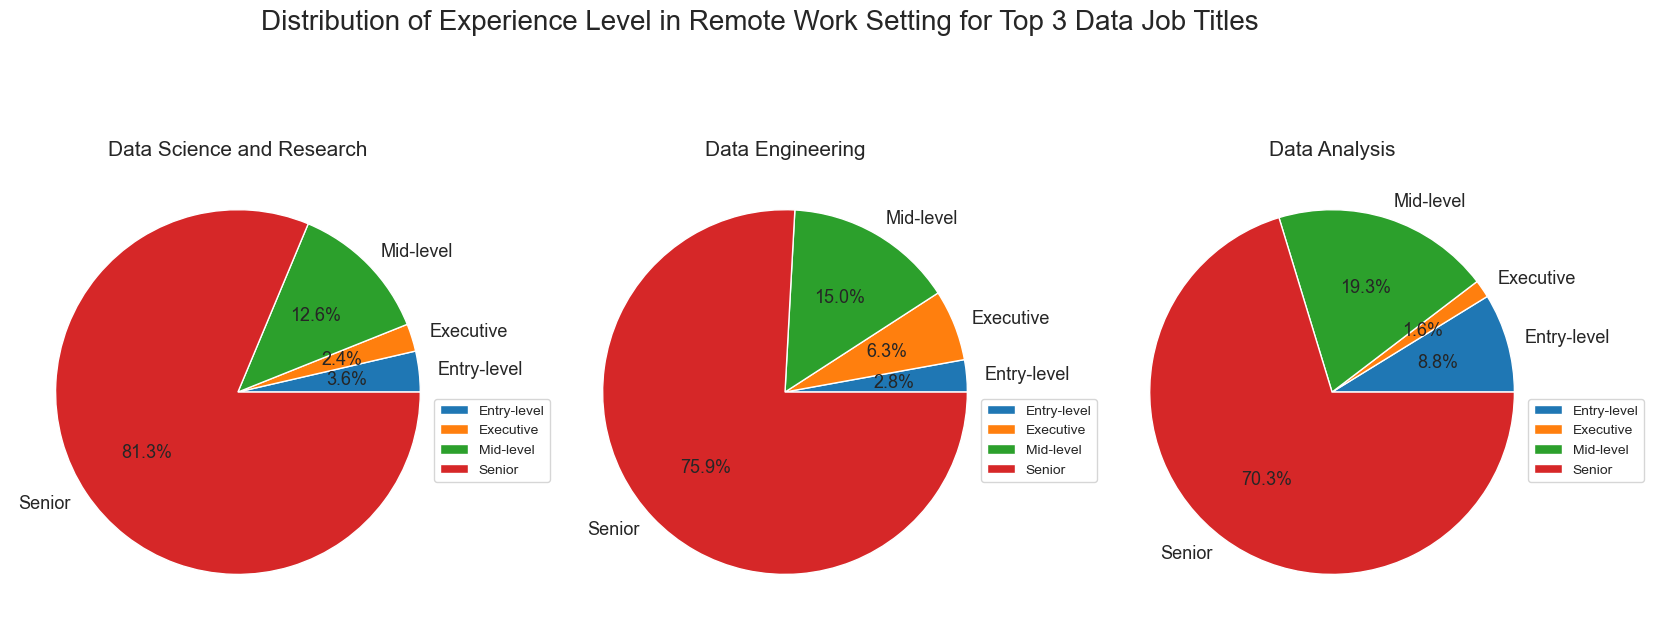

In [73]:
#clean code for 3 graphs

df_US_distribution = df_US_top3.groupby(['job_category', 'work_setting', 'experience_level'],dropna=False).size()
df_US_distribution = df_US_distribution.reset_index(name='job_count')
df_US_distribution = df_US_distribution[df_US_distribution['job_category'].isin(top_3_job)]
setting_work = ['Hybrid', 'In-person', 'Remote']
for work in setting_work:
    df_US_dist_plot = df_US_distribution[df_US_distribution['work_setting'] == work]
    df_US_dist_plot = df_US_dist_plot.set_index('job_category')

    fig,ax = plt.subplots(1,3, figsize=(20,15))
    for i,job in enumerate(top_3_job):
        ax[i].pie(data=df_US_dist_plot.loc[job], x='job_count', labels=df_US_dist_plot.loc[job]['experience_level'], autopct='%1.1f%%', textprops={'fontsize': 13})
        ax[i].set_title(job, fontsize=15)
        ax[i].legend(loc='upper right', bbox_to_anchor=(1.2,0.5))
    plt.suptitle(f'Distribution of Experience Level in {work} Work Setting for Top 3 Data Job Titles', y=0.75, fontsize=20)


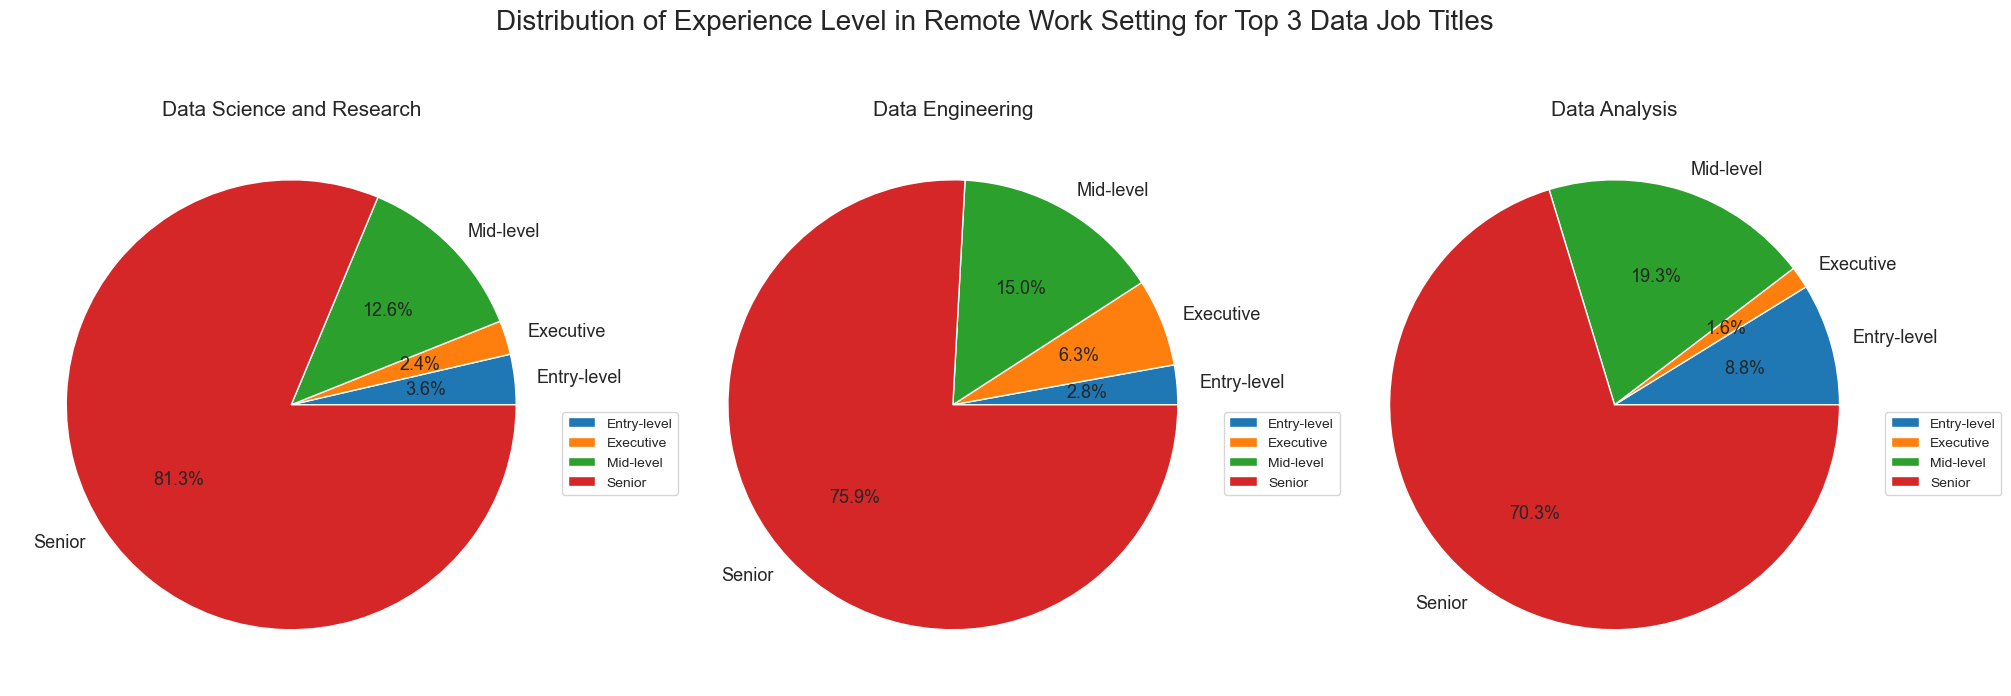

In [74]:
df_US_remote = df_US_distribution[df_US_distribution['job_category'].isin(top_3_job)]
df_US_remote = df_US_remote[df_US_remote['work_setting'] == 'Remote']
df_US_remote = df_US_remote.set_index('job_category')

fig,ax = plt.subplots(1,3, figsize=(20,15))
for i,job in enumerate(top_3_job):
    ax[i].pie(data=df_US_remote.loc[job], x='job_count', labels=df_US_remote.loc[job]['experience_level'], autopct='%1.1f%%', textprops={'fontsize': 13})
    ax[i].set_title(job, fontsize=15)
    ax[i].legend(loc='upper right', bbox_to_anchor=(1.2,0.5))
plt.suptitle('Distribution of Experience Level in Remote Work Setting for Top 3 Data Job Titles', y=0.75, fontsize=20)
plt.tight_layout()

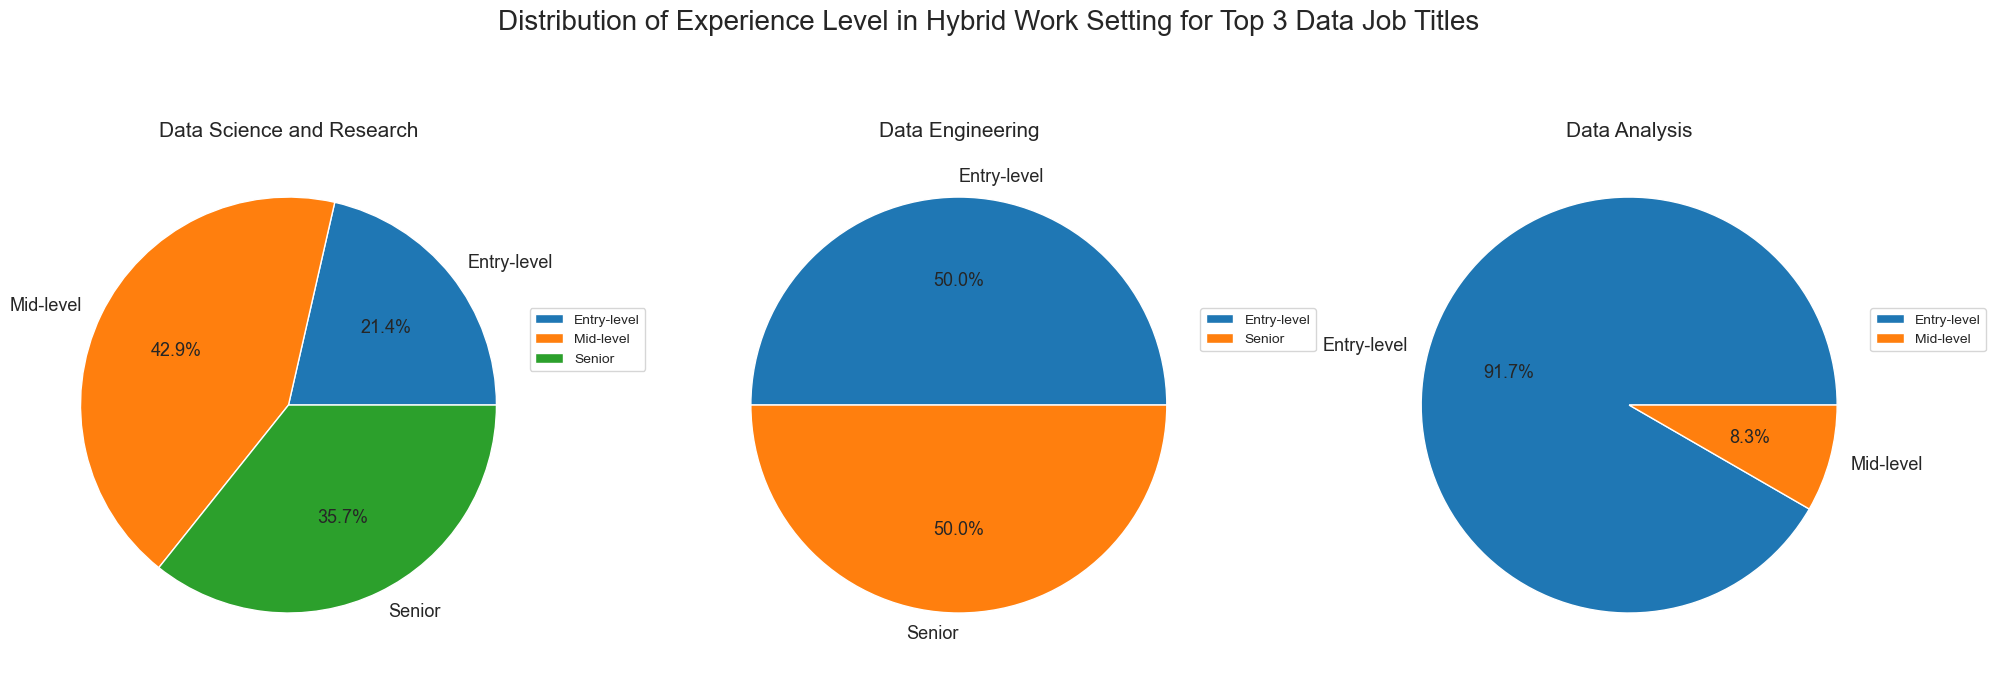

In [75]:
df_US_hybrid = df_US_distribution[df_US_distribution['job_category'].isin(top_3_job)]
df_US_hybrid = df_US_hybrid[df_US_hybrid['work_setting'] == 'Hybrid']
df_US_hybrid = df_US_hybrid.set_index('job_category')

fig,ax = plt.subplots(1,3, figsize=(20,15))
for i,job in enumerate(top_3_job):
    ax[i].pie(data=df_US_hybrid.loc[job], x='job_count', labels=df_US_hybrid.loc[job]['experience_level'], autopct='%1.1f%%', textprops={'fontsize': 13})
    ax[i].set_title(job, fontsize=15)
    ax[i].legend(loc='upper right', bbox_to_anchor=(1.2,0.7))
plt.suptitle('Distribution of Experience Level in Hybrid Work Setting for Top 3 Data Job Titles', y=0.75, fontsize=20)
plt.tight_layout()

#reason why mean salary for hybrid work setting is that it is dominated by entry-level experience, unlike the other two which are dominated by senior-level experience.


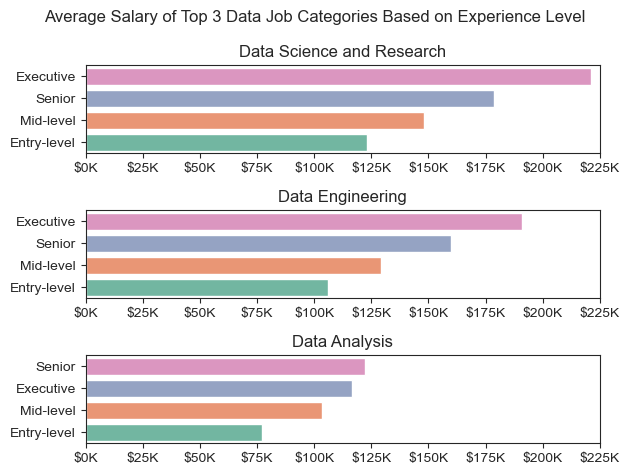

In [76]:
#explore the analysis for entry level experience only.
#eventually compare different job role for different experience to compare which salary growth is more rewarding.

mean_exp_level = df_US_top3.groupby(['job_category', 'experience_level'])['salary_in_usd'].mean()
mean_exp_level = mean_exp_level.reset_index(name='mean_salary')
mean_exp_level = mean_exp_level.sort_values(by='mean_salary', ascending=False)
fig, ax = plt.subplots(3,1)
sns.set_style(style='ticks')
for i,job in enumerate(top_3_job):
    mean_exp_level_plot = mean_exp_level[mean_exp_level['job_category'] == job]
    sns.barplot(data=mean_exp_level_plot, y='experience_level', x='mean_salary', legend=False, ax=ax[i], palette='Set2', hue='mean_salary')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,225000)
    ax[i].set_xlabel('')
    ax[i].set_title(job)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.suptitle('Average Salary of Top 3 Data Job Categories Based on Experience Level')
plt.tight_layout()
plt.show()

#data analyst has the lowest salary in all experience level
#data engineer has the highest salary for entry-level
#while data scientist has the largest growth over experience level.

<Axes: ylabel='Density'>

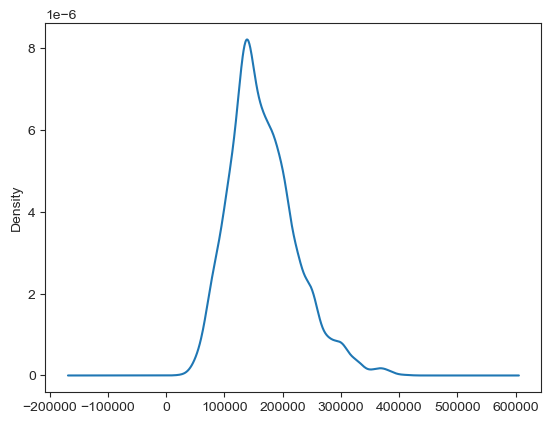

In [77]:
#WHY IN THE HELL IS SENIOR LEVEL HAS HIGHER MEAN SALARY THAN EXECUTIVE???

df_US_DA = df_US[df_US['job_category'] == 'Data Analysis']
df_US_DA = df_US[df_US['experience_level'].isin(['Senior'])]
df_US_DA['salary_in_usd'].plot(kind='kde')

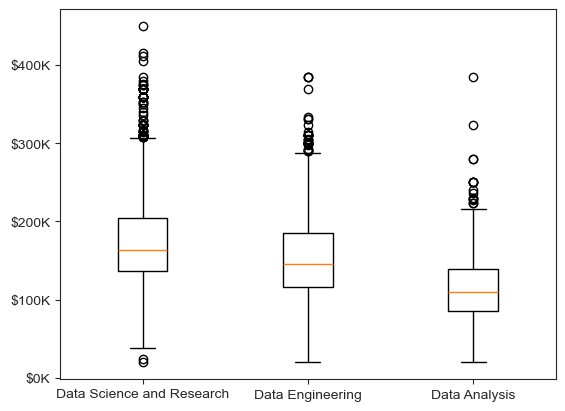

In [78]:
job_list = [df_US[df_US['job_category'] == job]['salary_in_usd']for job in top_3_job]
job_list

plt.boxplot(job_list, tick_labels=top_3_job)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.show()

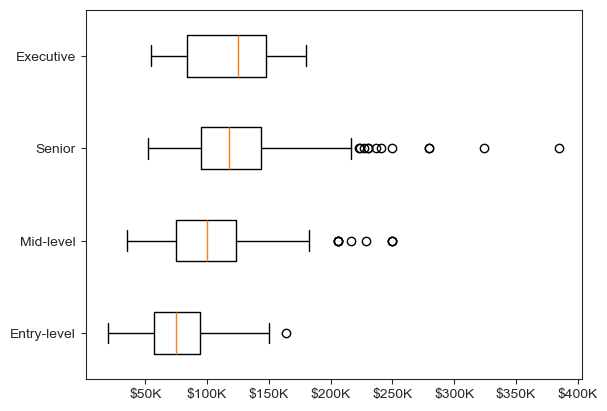

In [79]:
df_US_DA = df_US_top3[df_US_top3['job_category'] == 'Data Analysis']
experience = ['Entry-level', 'Mid-level', 'Senior', 'Executive']
DA_list = [df_US_DA[df_US_DA['experience_level'] == exp]['salary_in_usd'] for exp in experience]
DA_list

plt.boxplot(DA_list, tick_labels=experience, vert=False)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.show()

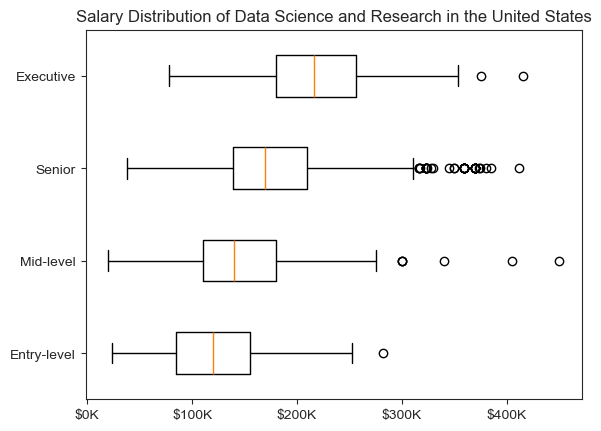

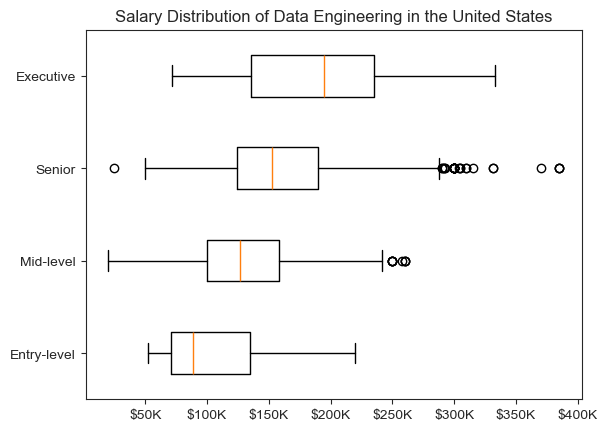

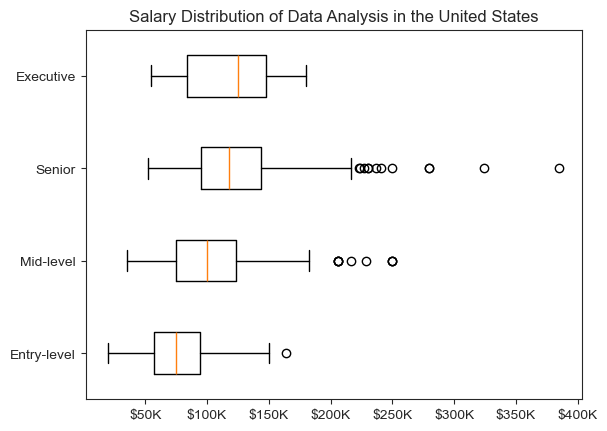

In [80]:
experience = ['Entry-level', 'Mid-level', 'Senior', 'Executive']
sns.set_style('ticks')
for job in top_3_job:
    df_US_DA = df_US_top3[df_US_top3['job_category'] == job]
    DA_list = [df_US_DA[df_US_DA['experience_level'] == exp]['salary_in_usd'] for exp in experience]
    plt.boxplot(DA_list, tick_labels=experience, vert=False)
    plt.title(f'Salary Distribution of {job} in the United States')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
    plt.show()

In [81]:
df_US[(df_US['salary_in_usd'] <= 50000) & (df_US['experience_level'] == 'Senior')]

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
1526,2023,Data Engineer,Data Engineering,USD,50000,50000,United States,Senior,Full-time,In-person,United States,M
2370,2023,Research Analyst,Data Science and Research,USD,50000,50000,United States,Senior,Full-time,In-person,United States,M
3888,2023,Data Lead,Leadership and Management,USD,38000,38000,United States,Senior,Full-time,In-person,United States,M
4328,2023,Data Visualization Specialist,BI and Visualization,USD,50000,50000,United States,Senior,Full-time,In-person,United States,M
8252,2022,Data Scientist,Data Science and Research,USD,38000,38000,United States,Senior,Full-time,Remote,United States,M
8256,2022,Data Scientist,Data Science and Research,USD,38000,38000,United States,Senior,Full-time,Remote,United States,M
8262,2022,Data Scientist,Data Science and Research,USD,50000,50000,United States,Senior,Full-time,Remote,United States,M
8266,2022,Data Scientist,Data Science and Research,USD,38000,38000,United States,Senior,Full-time,Remote,United States,M
8288,2022,Data Engineer,Data Engineering,USD,50000,50000,United States,Senior,Full-time,Remote,United States,M
8304,2022,Data Scientist,Data Science and Research,USD,50000,50000,United States,Senior,Full-time,Remote,United States,M
